<a href="https://colab.research.google.com/github/HoneyAdeleke/Gender_Based_Violence/blob/main/AIRI_Inflation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for academic presentation
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'figure.titlesize': 14})

In [4]:
# 1. LOAD DATASET
# The original path "C:\Users\DRACCO RESEARCH\Desktop\UI\CAPE\aeri inflation.csv" is a local Windows path
# and is not accessible in Google Colab's cloud environment.
# Please upload your 'aeri inflation.csv' file to the Colab environment or mount Google Drive.
# For example, after uploading, the file might be directly in the content directory:
file_path = "aeri inflation.csv" # Update this path after uploading your file

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Could not find file at: {file_path}. Please ensure the file is uploaded and the path is correct.")

df = pd.read_csv(file_path)

# Ensure proper data types
df['Period'] = pd.to_datetime(df['Period'], format='%Y-%m')
df['InflationRisk'] = pd.to_numeric(df['InflationRisk'], errors='coerce')
df['InflationRate'] = pd.to_numeric(df['InflationRate'], errors='coerce')
df = df.dropna(subset=['Country', 'Period', 'InflationRisk', 'InflationRate'])

In [5]:
# 2. DEFINE STRUCTURAL GROUPINGS (MAPPINGS)
regions = {
    # North Africa
    'Algeria': 'North Africa',
    'Egypt': 'North Africa',
    'Libya': 'North Africa',
    'Morocco': 'North Africa',
    'Tunisia': 'North Africa',

    # West Africa
    'Benin': 'West Africa',
    'Burkina Faso': 'West Africa',
    'Cape Verde': 'West Africa',
    'Cabo Verde': 'West Africa',   # Use whichever name appears in your dataset
    "Cote d'Ivoire": 'West Africa',
    'Ivory Coast': 'West Africa',  # Optional alias
    'Gambia': 'West Africa',
    'Ghana': 'West Africa',
    'Guinea': 'West Africa',
    'Guinea-Bissau': 'West Africa',
    'Liberia': 'West Africa',
    'Mali': 'West Africa',
    'Mauritania': 'West Africa',
    'Niger': 'West Africa',
    'Nigeria': 'West Africa',
    'Senegal': 'West Africa',
    'Sierra Leone': 'West Africa',
    'Togo': 'West Africa',

    # Central Africa
    'Angola': 'Central Africa',
    'Cameroon': 'Central Africa',
    'Central African Republic': 'Central Africa',
    'Chad': 'Central Africa',
    'Republic of the Congo': 'Central Africa',
    'Congo': 'Central Africa',      # Optional alias
    'Democratic Republic of the Congo': 'Central Africa',
    'DR Congo': 'Central Africa',   # Optional alias
    'Sao Tome and Principe': 'Central Africa',

    # East Africa
    'Burundi': 'East Africa',
    'Djibouti': 'East Africa',
    'Ethiopia': 'East Africa',
    'Kenya': 'East Africa',
    'Madagascar': 'East Africa',
    'Malawi': 'East Africa',
    'Mozambique': 'East Africa',
    'Rwanda': 'East Africa',
    'South Sudan': 'East Africa',
    'Sudan': 'East Africa',
    'Tanzania': 'East Africa',
    'Uganda': 'East Africa',
    'Zambia': 'East Africa',
    'Zimbabwe': 'East Africa',

    # Southern Africa
    'Botswana': 'Southern Africa',
    'Eswatini': 'Southern Africa',
    'Swaziland': 'Southern Africa',   # Optional alias
    'Lesotho': 'Southern Africa',
    'Namibia': 'Southern Africa',
    'South Africa': 'Southern Africa'
}

economic_structures = {
    'Algeria': 'Oil/Resource Exporter', 'Angola': 'Oil/Resource Exporter',
    'Nigeria': 'Oil/Resource Exporter', 'Libya': 'Oil/Resource Exporter',
    'Egypt': 'Diversified/Non-Resource', 'Morocco': 'Diversified/Non-Resource',
    'Kenya': 'Diversified/Non-Resource', 'South Africa': 'Diversified/Non-Resource',
    # Add other panel countries here...
}

# Map groupings to dataframe (default to 'Other' if not explicitly defined above)
df['Region'] = df['Country'].map(regions).fillna('Other Regions')
df['EconomicGroup'] = df['Country'].map(economic_structures).fillna('Other Economies')

print("--- Dataset Summary Statistics ---")
print(df[['InflationRisk', 'InflationRate']].describe())

--- Dataset Summary Statistics ---
       InflationRisk  InflationRate
count    5999.000000    5999.000000
mean        4.580239      12.152910
std         5.425322      37.200531
min         0.000000     -13.300000
25%         1.196548       2.500000
50%         3.221553       5.400000
75%         6.039897      10.600000
max        80.000001     785.600000


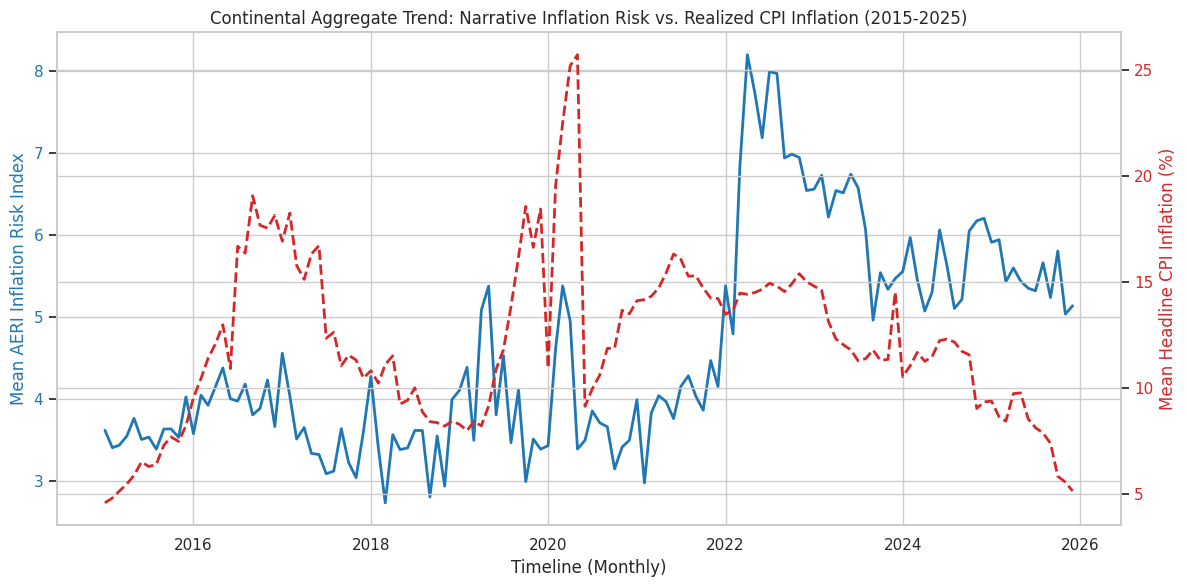

In [8]:
# Figure 2: Regional Dual-Axis Time Series Trend (Aggregated Example)
# Aggregating data across the entire panel to show macro movement across time
panel_ts = df.groupby('Period')[['InflationRisk', 'InflationRate']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

color = '#1f77b4'
ax1.set_xlabel('Timeline (Monthly)')
ax1.set_ylabel('Mean AERI Inflation Risk Index', color=color)
ax1.plot(panel_ts['Period'], panel_ts['InflationRisk'], color=color, linewidth=2, label='Inflation Risk (Left)')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = '#d62728'
ax2.set_ylabel('Mean Headline CPI Inflation (%)', color=color)
ax2.plot(panel_ts['Period'], panel_ts['InflationRate'], color=color, linewidth=2, linestyle='--', label='Actual CPI (Right)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Continental Aggregate Trend: Narrative Inflation Risk vs. Realized CPI Inflation (2015-2025)')
fig.tight_layout()
plt.savefig('continental_trend_comparison.png', dpi=300)
plt.show()

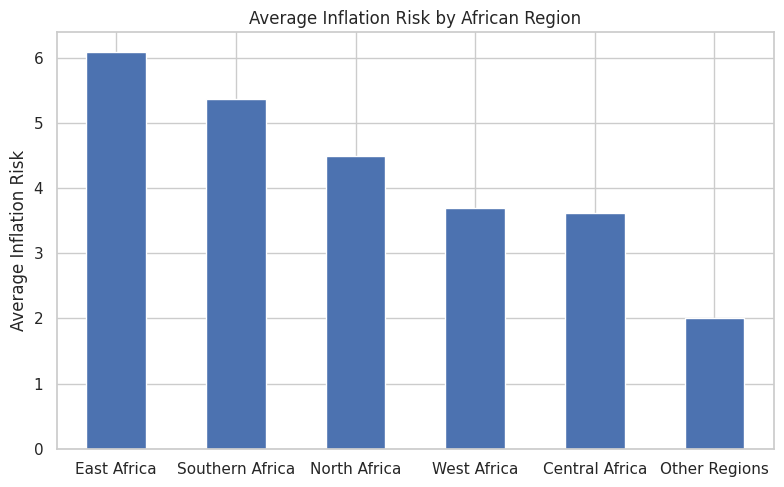

In [10]:
# Add region variable
df['region'] = df['Country'].map(regions)

region_avg = (
    df.groupby('Region')['InflationRisk']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
region_avg.plot(kind='bar')
plt.title('Average Inflation Risk by African Region')
plt.ylabel('Average Inflation Risk')
plt.xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Verification using 15 Countries**

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Set plotting style for academic presentation
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'figure.titlesize': 14})

In [28]:
# 1. LOAD AND FILTER DATASET
file_path = "/content/aeri inflation.csv" # Updated path for Colab
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Could not find file at: {file_path}")

df = pd.read_csv(file_path)

# Ensure proper data types
df['Period'] = pd.to_datetime(df['Period'], format='%Y-%m')
df['InflationRisk'] = pd.to_numeric(df['InflationRisk'], errors='coerce')
df['InflationRate'] = pd.to_numeric(df['InflationRate'], errors='coerce')

# Define your exact 15 focus countries
target_countries = [
    "Nigeria", "Egypt", "South Africa", "Algeria", "Morocco",
    "Ethiopia", "Angola", "Kenya", "Ivory Coast", "Ghana",
    "Tanzania", "Congo DRC", "Libya", "Uganda", "Tunisia"
]

# Keep only the target countries and drop rows with missing values
df = df[df['Country'].isin(target_countries)].copy()
df = df.dropna(subset=['Country', 'Period', 'InflationRisk', 'InflationRate'])

In [30]:
# 2. STRUCTURAL GROUPINGS FOR YOUR 15 COUNTRIES
regions = {
    'Nigeria': 'West Africa', 'Ghana': 'West Africa', "Ivory Coast": 'West Africa',
    'Egypt': 'North Africa', 'Algeria': 'North Africa', 'Morocco': 'North Africa', 'Libya': 'North Africa', 'Tunisia': 'North Africa',
    'Kenya': 'East Africa', 'Ethiopia': 'East Africa', 'Uganda': 'East Africa', 'Tanzania': 'East Africa',
    'South Africa': 'Southern Africa', 'Angola': 'Southern Africa',
    'Congo DRC': 'Central Africa'
}

economic_structures = {
    'Nigeria': 'Oil & Mineral Exporter',
    'Angola': 'Oil & Mineral Exporter',
    'Algeria': 'Oil & Mineral Exporter',
    'Libya': 'Oil & Mineral Exporter',
    'Congo DRC': 'Oil & Mineral Exporter',
    'South Africa': 'Diversified/Non-Resource',
    'Egypt': 'Diversified/Non-Resource',
    'Morocco': 'Diversified/Non-Resource',
    'Tunisia': 'Diversified/Non-Resource',
    'Kenya': 'Diversified/Non-Resource',
    'Ethiopia': 'Diversified/Non-Resource',
    'Ghana': 'Diversified/Non-Resource',
    "Ivory Coast": 'Diversified/Non-Resource',
    'Tanzania': 'Diversified/Non-Resource',
    'Uganda': 'Diversified/Non-Resource'
}

# Map groupings to dataframe
df['Region'] = df['Country'].map(regions)
df['EconomicGroup'] = df['Country'].map(economic_structures)

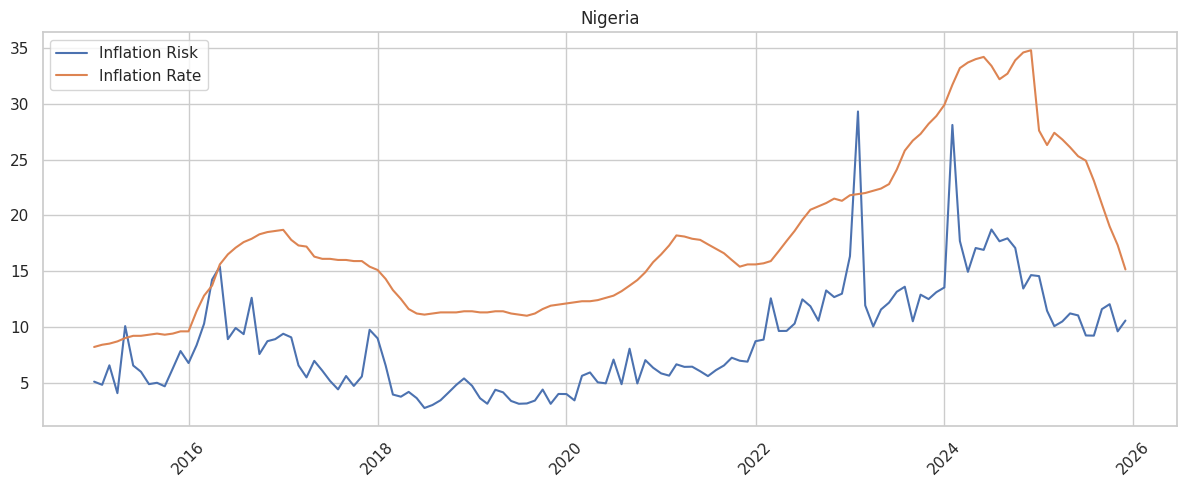

In [32]:
country = "Nigeria"

temp = df[df['Country']==country]

plt.figure(figsize=(12,5))

plt.plot(temp['Period'],
         temp['InflationRisk'],
         label="Inflation Risk")

plt.plot(temp['Period'],
         temp['InflationRate'],
         label="Inflation Rate")

plt.title(country)

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.show()

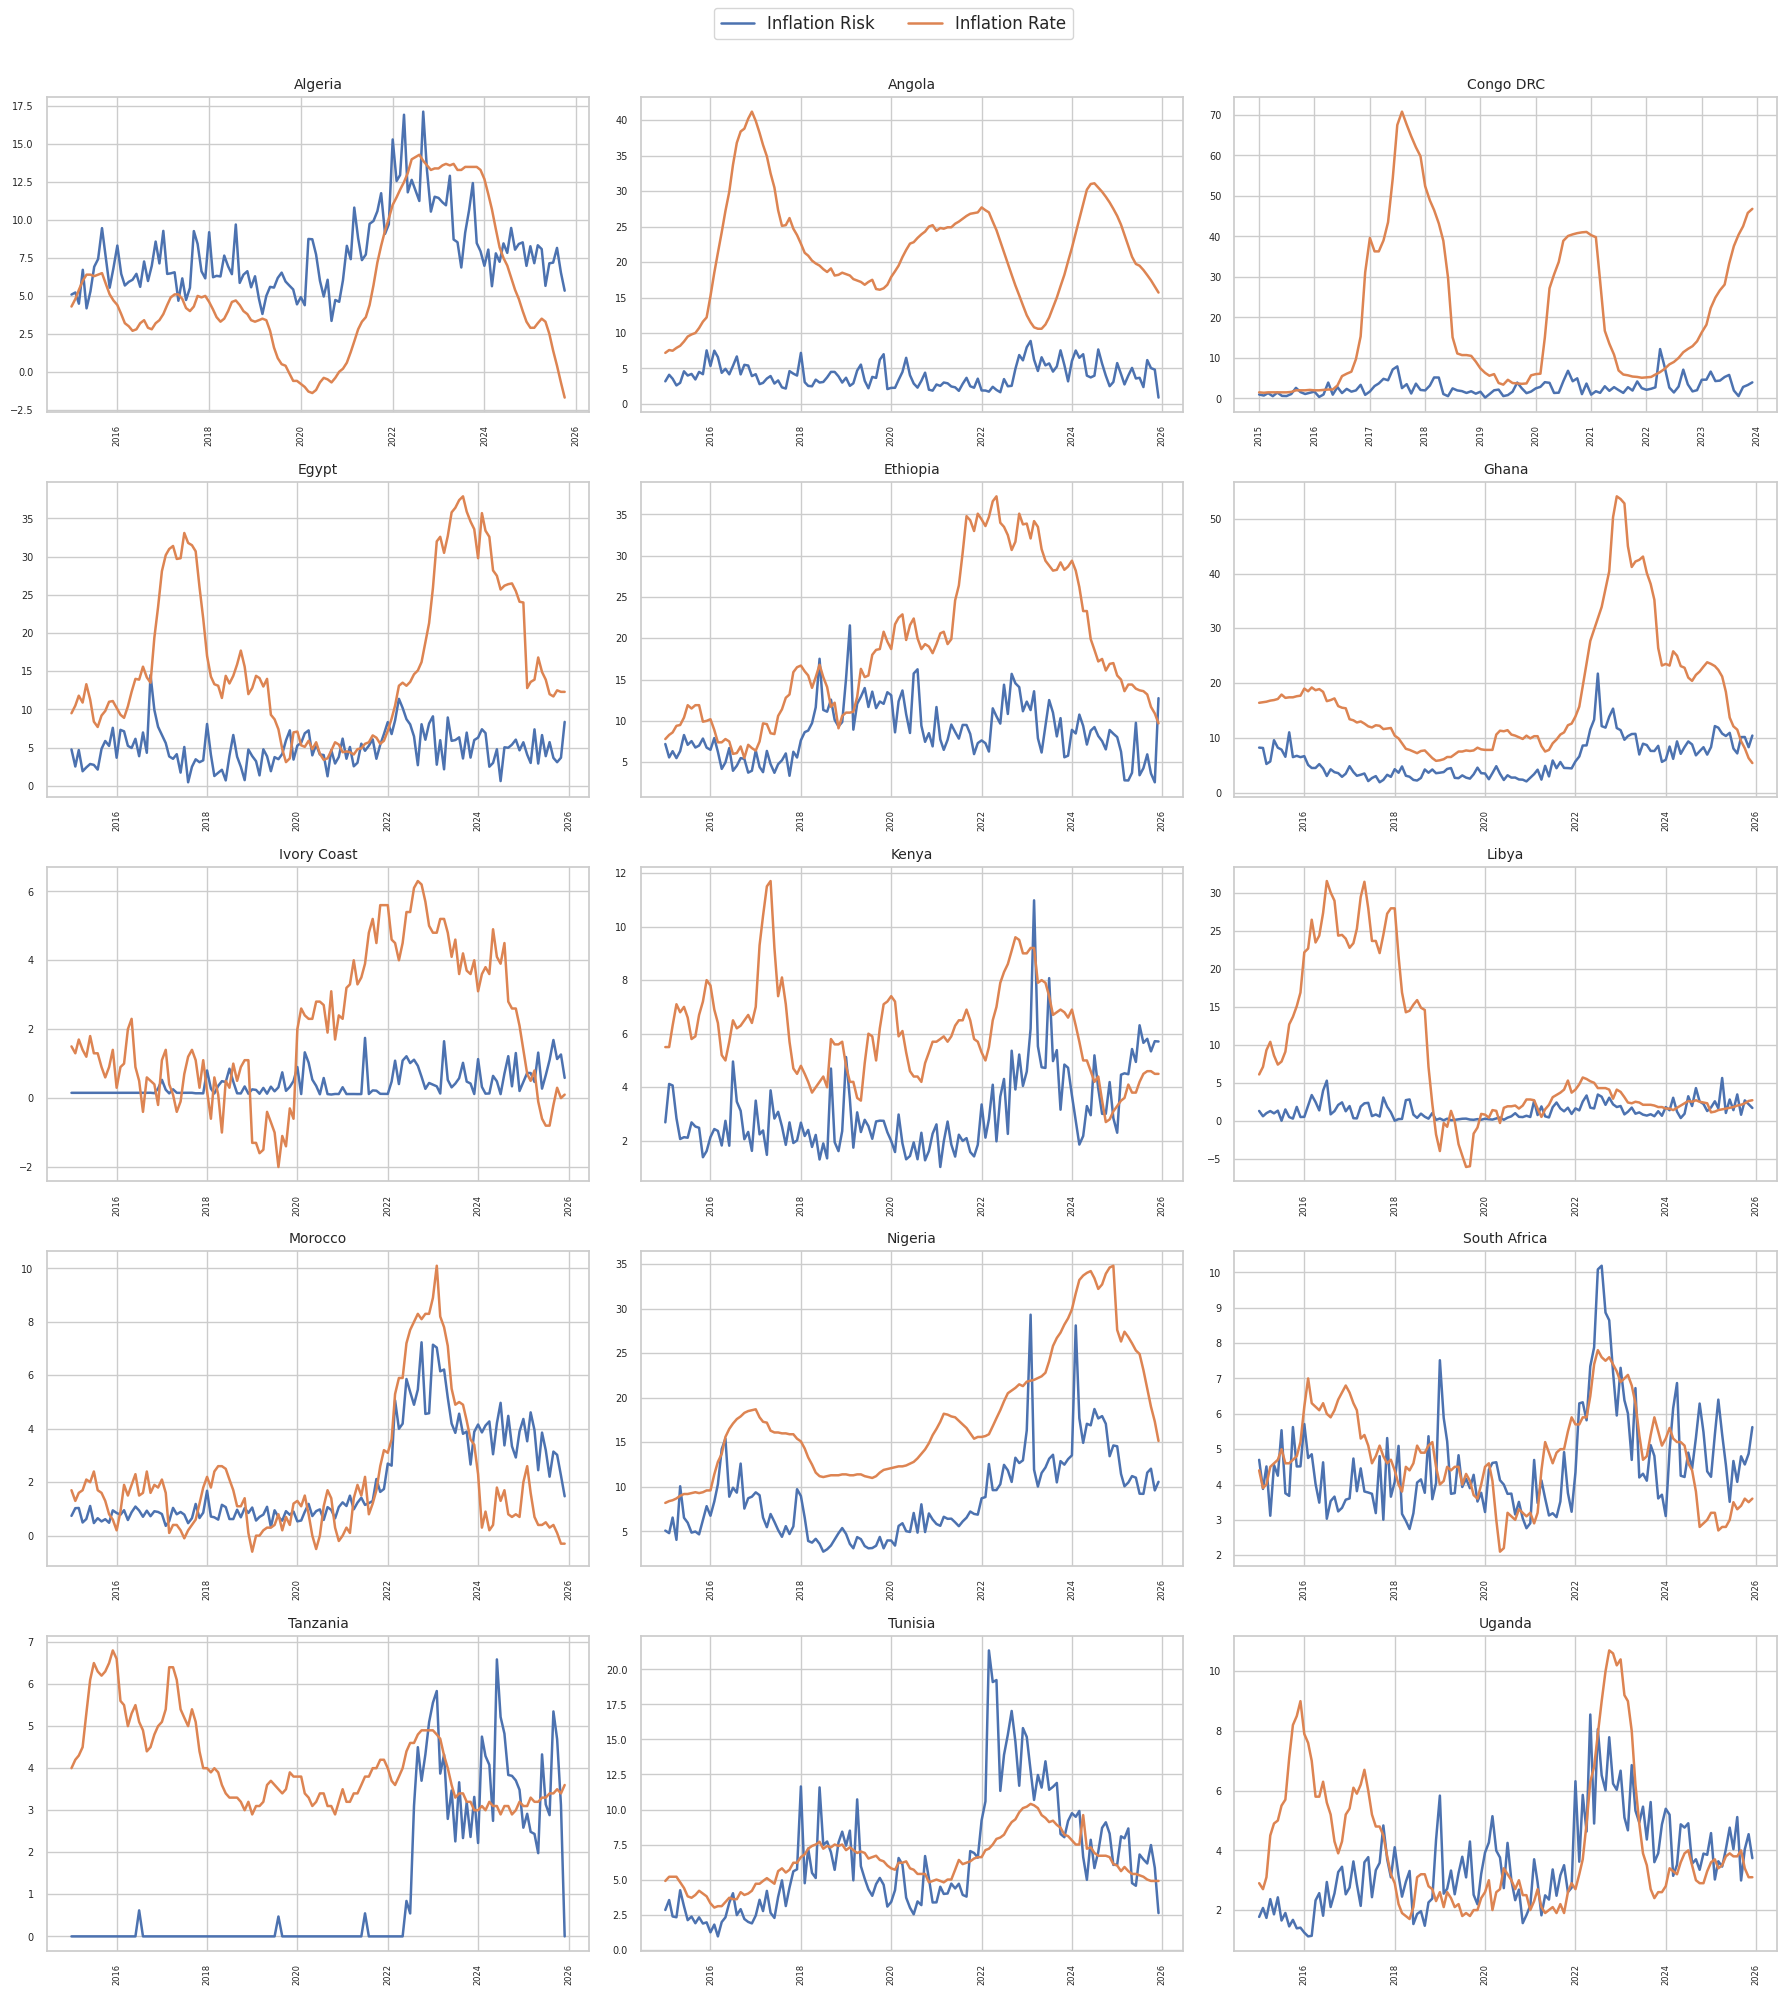

In [33]:
import matplotlib.pyplot as plt

countries = sorted(df['Country'].unique())

ncols = 3
nrows = (len(countries) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows,
                         ncols=ncols,
                         figsize=(18, 4*nrows),
                         sharex=False)

axes = axes.flatten()

for ax, country in zip(axes, countries):

    temp = df[df['Country'] == country].sort_values('Period')

    ax.plot(temp['Period'],
            temp['InflationRisk'],
            label='Inflation Risk',
            linewidth=1.8)

    ax.plot(temp['Period'],
            temp['InflationRate'],
            label='Inflation Rate',
            linewidth=1.8)

    ax.set_title(country, fontsize=10)
    ax.tick_params(axis='x', rotation=90, labelsize=6)
    ax.tick_params(axis='y', labelsize=7)

# Remove unused panels
for i in range(len(countries), len(axes)):
    fig.delaxes(axes[i])

# One legend for the entire figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='upper center',
           ncol=2,
           fontsize=12)

plt.tight_layout(rect=[0,0,1,0.97])

plt.show()

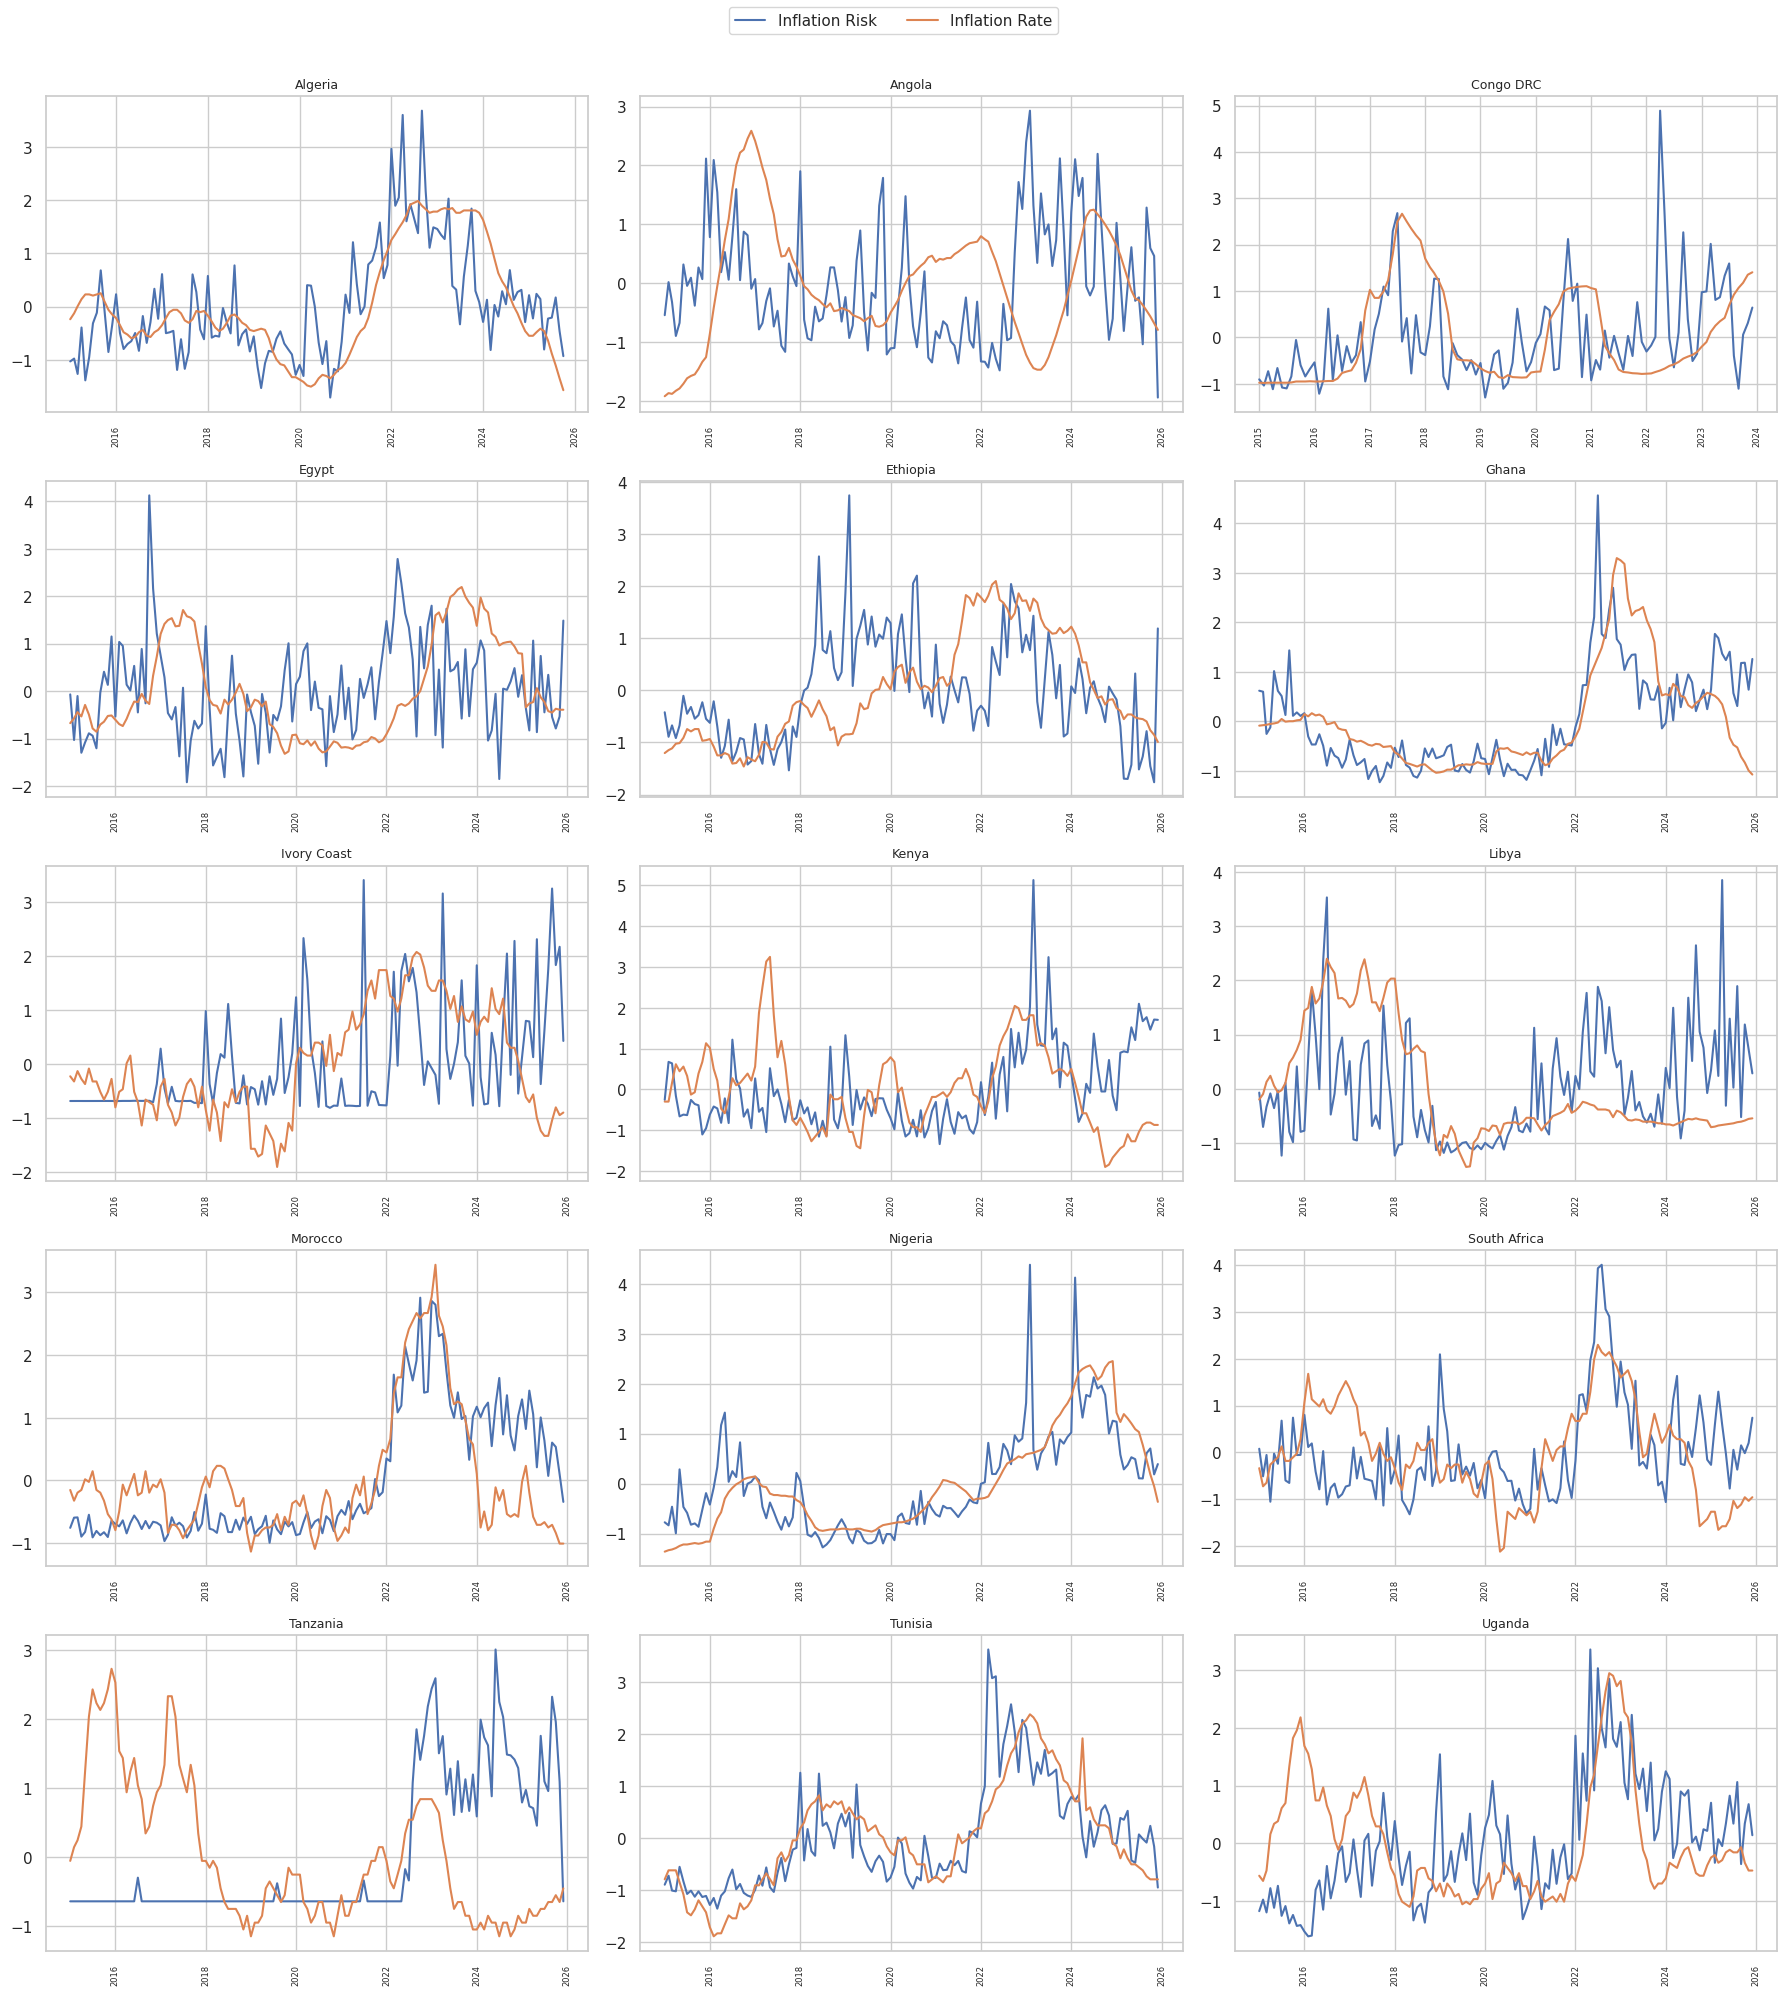

In [34]:
from scipy.stats import zscore

df['InflationRisk_z'] = df.groupby('Country')['InflationRisk'].transform(zscore)

df['InflationRate_z'] = df.groupby('Country')['InflationRate'].transform(zscore)

countries = sorted(df['Country'].unique())

ncols = 3
nrows = (len(countries) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows,
                         ncols,
                         figsize=(18,4*nrows))

axes = axes.flatten()

for ax, country in zip(axes, countries):

    temp = df[df['Country']==country].sort_values('Period')

    ax.plot(temp['Period'],
            temp['InflationRisk_z'],
            label='Inflation Risk')

    ax.plot(temp['Period'],
            temp['InflationRate_z'],
            label='Inflation Rate')

    ax.set_title(country, fontsize=9)
    ax.tick_params(axis='x', rotation=90, labelsize=6)

for i in range(len(countries), len(axes)):
    fig.delaxes(axes[i])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)

plt.tight_layout(rect=[0,0,1,0.97])

plt.show()

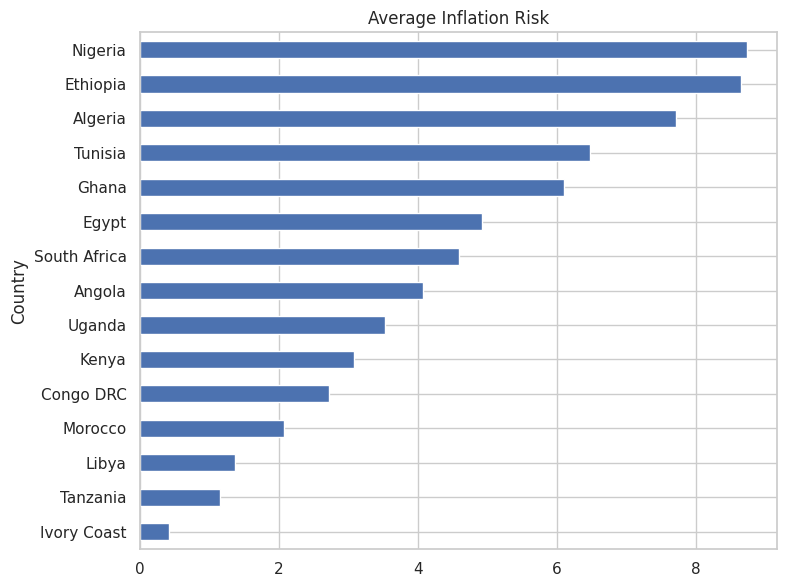

In [35]:
country_mean = (
    df.groupby('Country')['InflationRisk']
          .mean()
          .sort_values()
)

plt.figure(figsize=(8,6))

country_mean.plot(kind='barh')

plt.title("Average Inflation Risk")

plt.tight_layout()

plt.show()

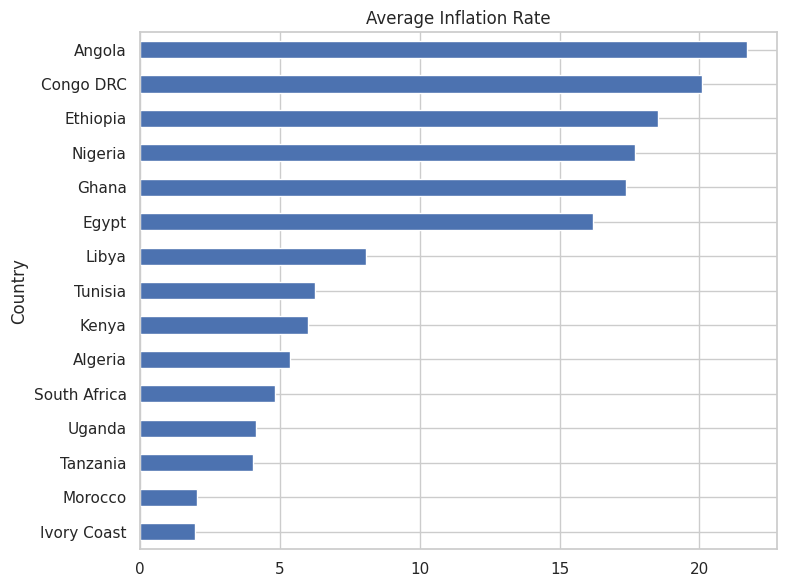

In [36]:
country_inf = (
    df.groupby('Country')['InflationRate']
          .mean()
          .sort_values()
)

plt.figure(figsize=(8,6))

country_inf.plot(kind='barh')

plt.title("Average Inflation Rate")

plt.tight_layout()

plt.show()

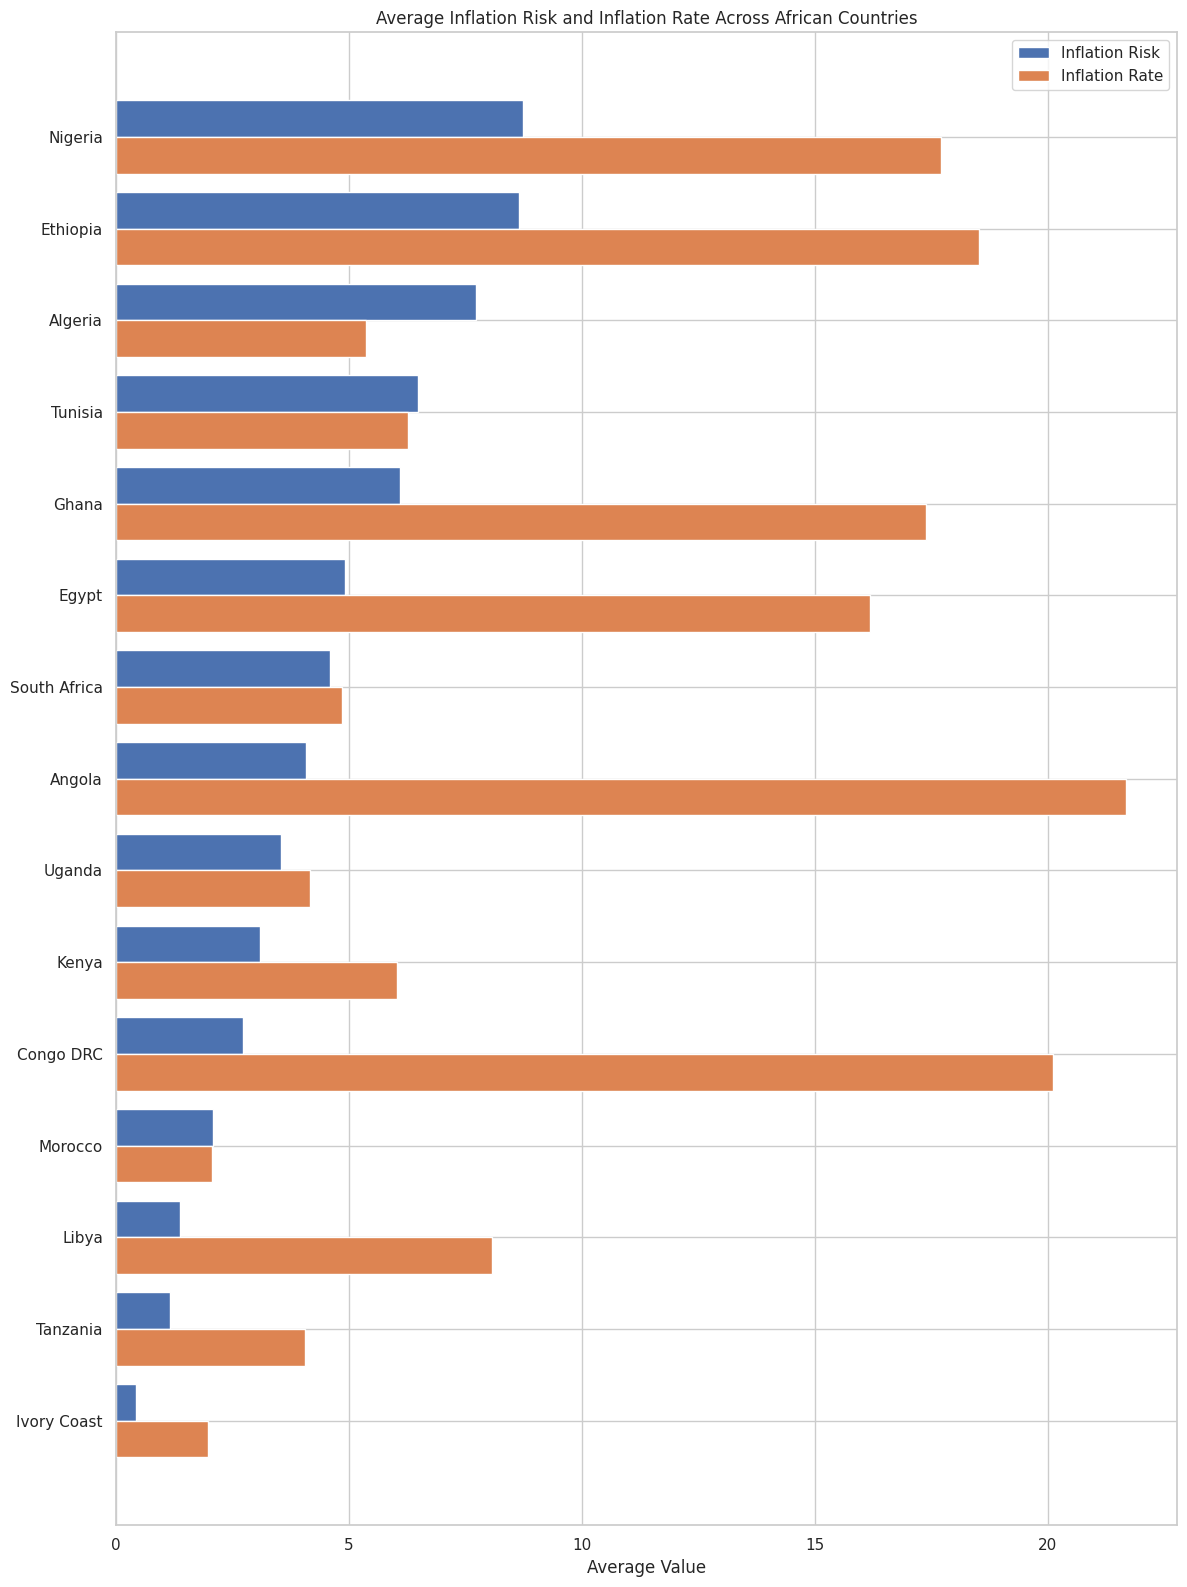

In [37]:
# Compute country averages
country_avg = (
    df.groupby('Country')[['InflationRisk', 'InflationRate']]
      .mean()
      .sort_values('InflationRisk', ascending=False)
)

y = np.arange(len(country_avg))
height = 0.4

plt.figure(figsize=(12,16))

plt.barh(
    y - height/2,
    country_avg['InflationRisk'],
    height,
    label='Inflation Risk'
)

plt.barh(
    y + height/2,
    country_avg['InflationRate'],
    height,
    label='Inflation Rate'
)

plt.yticks(y, country_avg.index)

plt.xlabel("Average Value")

plt.title("Average Inflation Risk and Inflation Rate Across African Countries")

plt.legend()

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [42]:
country_corr = (
    df.groupby('Country')
      .apply(lambda x: x['InflationRisk'].corr(x['InflationRate']))
      .reset_index()
)

country_corr.columns = ['Country', 'Correlation']

country_corr = country_corr.sort_values(
    'Correlation',
    ascending=False
)

print(country_corr)

         Country  Correlation
13       Tunisia     0.784888
10       Nigeria     0.777728
9        Morocco     0.723714
5          Ghana     0.691729
0        Algeria     0.664842
11  South Africa     0.409439
4       Ethiopia     0.373961
2      Congo DRC     0.304529
14        Uganda     0.278192
8          Libya     0.188181
6    Ivory Coast     0.164323
7          Kenya     0.127574
3          Egypt     0.014491
1         Angola    -0.141376
12      Tanzania    -0.256741


/tmp/ipykernel_1392/589810423.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['InflationRisk'].corr(x['InflationRate']))


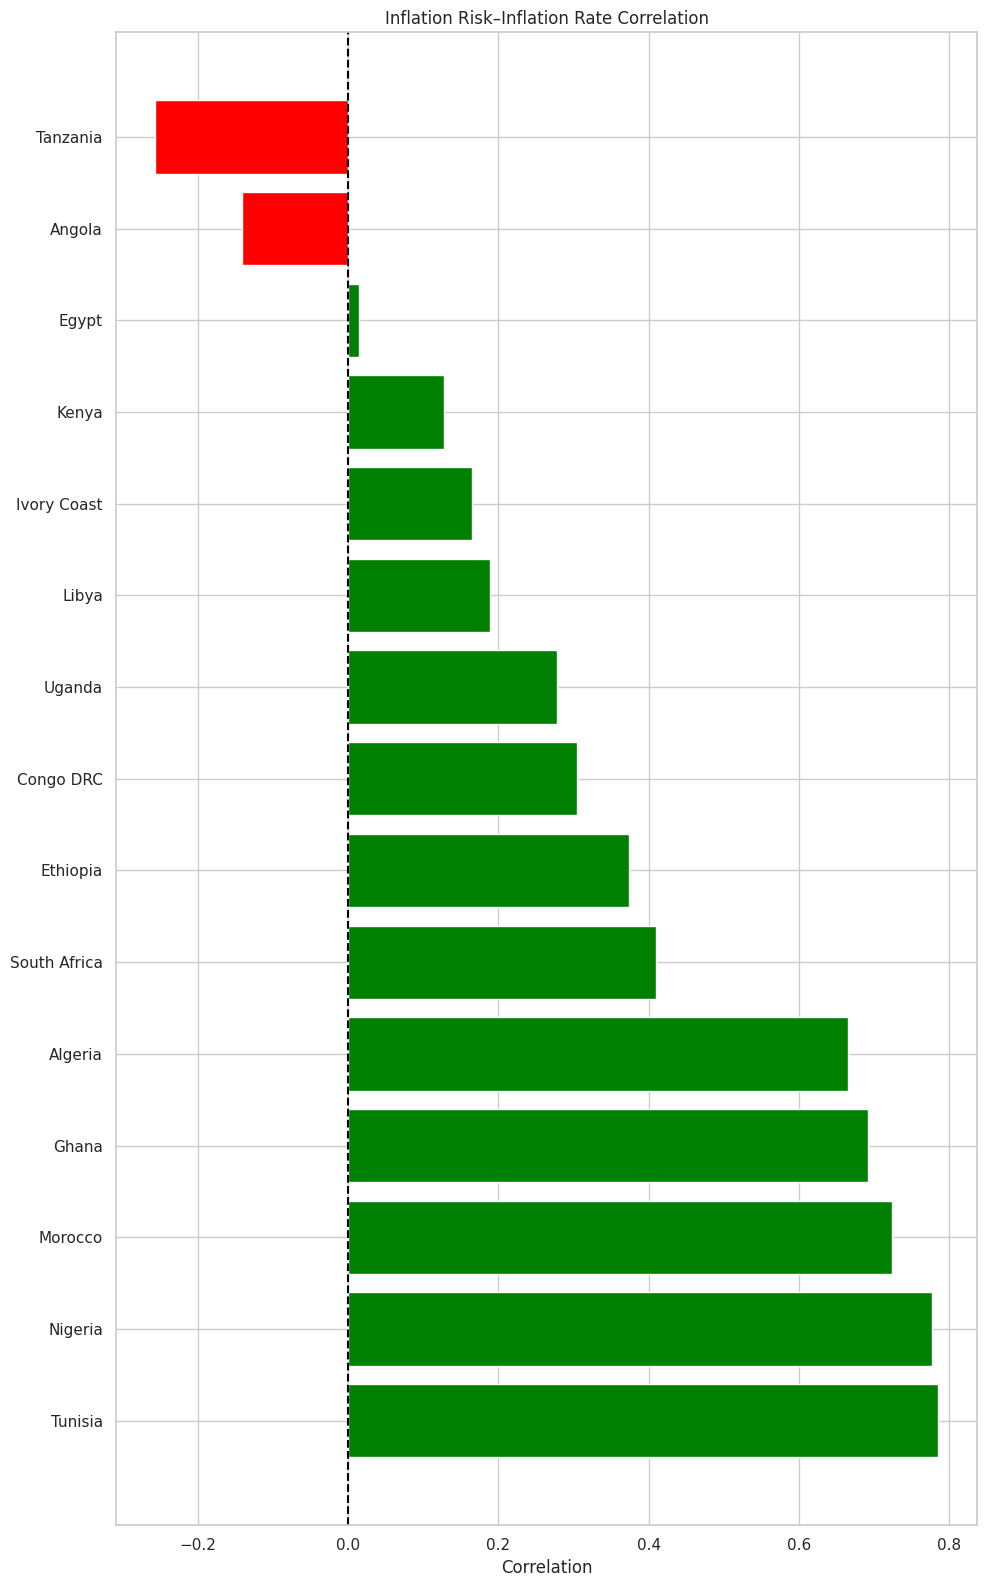

In [44]:
colors = [
    'green' if x > 0 else 'red'
    for x in country_corr['Correlation']
]

plt.figure(figsize=(10,16))

plt.barh(
    country_corr['Country'],
    country_corr['Correlation'],
    color=colors
)

plt.axvline(0,
            color='black',
            linestyle='--')

plt.xlabel("Correlation")

plt.title("Inflation Risk–Inflation Rate Correlation")

plt.tight_layout()

plt.show()

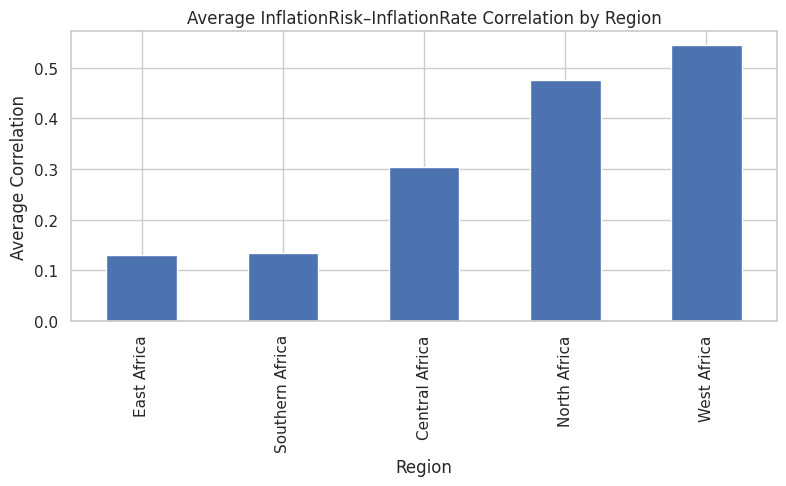

In [46]:
country_corr['Region'] = country_corr['Country'].map(regions)

region_corr = (
    country_corr.groupby('Region')['Correlation']
                .mean()
                .sort_values()
)

plt.figure(figsize=(8,5))

region_corr.plot(kind='bar')

plt.ylabel("Average Correlation")

plt.title("Average InflationRisk–InflationRate Correlation by Region")

plt.tight_layout()

plt.show()

In [47]:
def corr_strength(r):
    if r >= 0.70:
        return 'Very Strong'
    elif r >= 0.50:
        return 'Strong'
    elif r >= 0.30:
        return 'Moderate'
    elif r >= 0.10:
        return 'Weak'
    elif r > -0.10:
        return 'Negligible'
    else:
        return 'Negative'

country_corr['Strength'] = country_corr['Correlation'].apply(corr_strength)

print(country_corr)

         Country  Correlation           Region     Strength
13       Tunisia     0.784888     North Africa  Very Strong
10       Nigeria     0.777728      West Africa  Very Strong
9        Morocco     0.723714     North Africa  Very Strong
5          Ghana     0.691729      West Africa       Strong
0        Algeria     0.664842     North Africa       Strong
11  South Africa     0.409439  Southern Africa     Moderate
4       Ethiopia     0.373961      East Africa     Moderate
2      Congo DRC     0.304529   Central Africa     Moderate
14        Uganda     0.278192      East Africa         Weak
8          Libya     0.188181     North Africa         Weak
6    Ivory Coast     0.164323      West Africa         Weak
7          Kenya     0.127574      East Africa         Weak
3          Egypt     0.014491     North Africa   Negligible
1         Angola    -0.141376  Southern Africa     Negative
12      Tanzania    -0.256741      East Africa     Negative


In [48]:
print(len(target_countries))
print(df['Country'].nunique())
print(df['Country'].unique())

15
15
['Algeria' 'Angola' 'Congo DRC' 'Egypt' 'Ethiopia' 'Ghana' 'Ivory Coast'
 'Kenya' 'Libya' 'Morocco' 'Nigeria' 'South Africa' 'Tanzania' 'Tunisia'
 'Uganda']


In [49]:
# Map countries to regions
df['Region'] = df['Country'].map(regions)

# Compute regional correlations
region_corr = (
    df.groupby('Region')
      .apply(lambda x: x['InflationRisk'].corr(x['InflationRate']))
      .reset_index(name='Correlation')
)

print(region_corr)

            Region  Correlation
0   Central Africa     0.304529
1      East Africa     0.700168
2     North Africa     0.168028
3  Southern Africa    -0.171303
4      West Africa     0.811250


/tmp/ipykernel_1392/56471134.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['InflationRisk'].corr(x['InflationRate']))


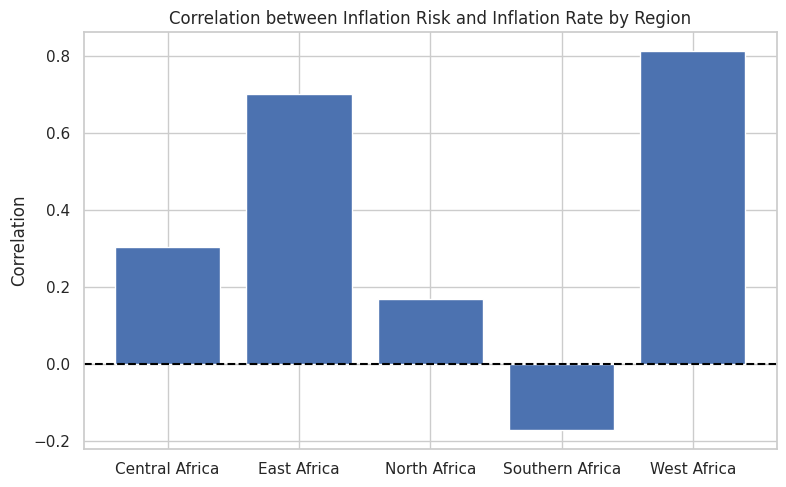

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    region_corr['Region'],
    region_corr['Correlation']
)

plt.axhline(0,
            color='black',
            linestyle='--')

plt.ylabel("Correlation")

plt.title("Correlation between Inflation Risk and Inflation Rate by Region")

plt.tight_layout()

plt.show()

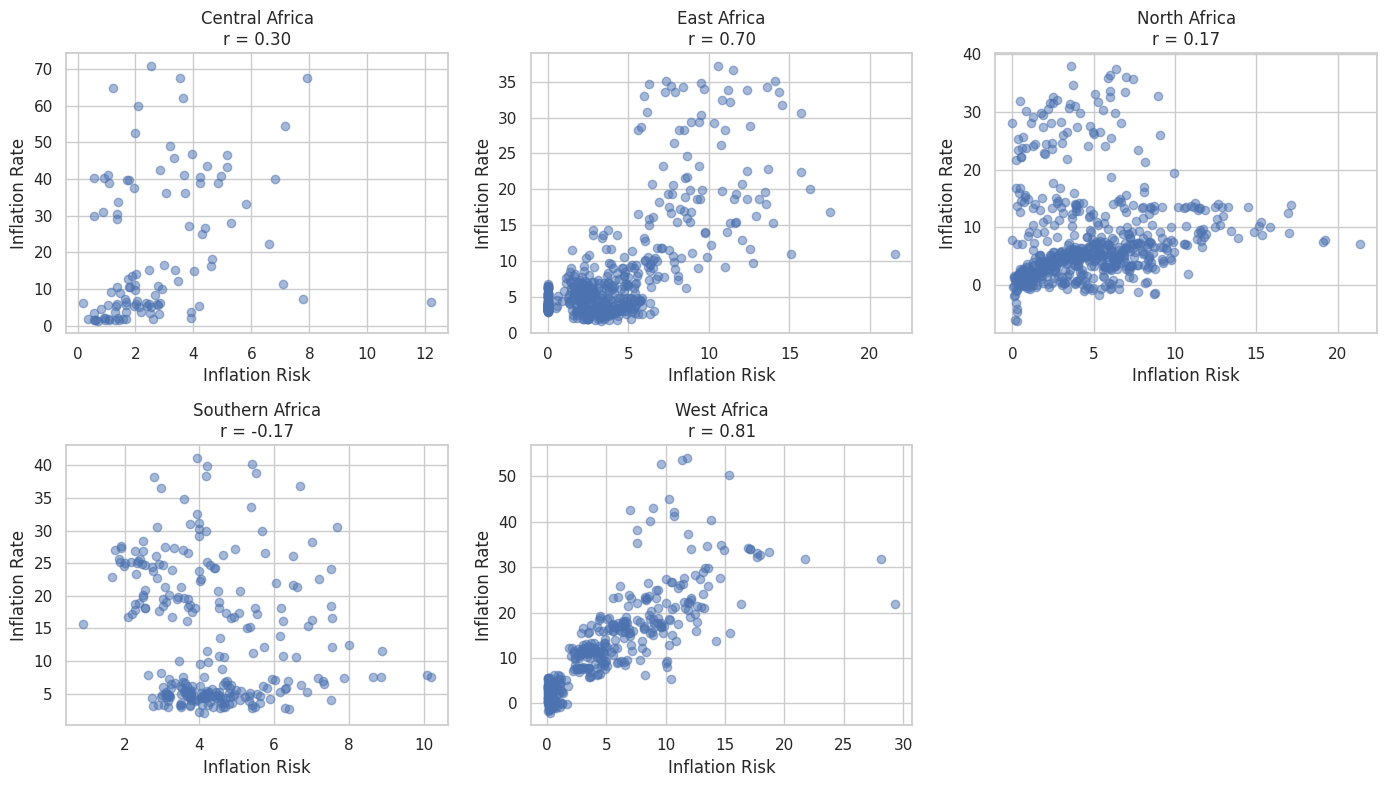

In [51]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes = axes.flatten()

regions_list = sorted(df['Region'].dropna().unique())

for ax, region in zip(axes, regions_list):

    temp = df[df['Region'] == region]

    ax.scatter(
        temp['InflationRisk'],
        temp['InflationRate'],
        alpha=0.5
    )

    corr = temp['InflationRisk'].corr(temp['InflationRate'])

    ax.set_title(f"{region}\nr = {corr:.2f}")

    ax.set_xlabel("Inflation Risk")
    ax.set_ylabel("Inflation Rate")

# Remove empty subplot if only 5 regions
for i in range(len(regions_list), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()

plt.show()

In [52]:
country_corr = (
    df.groupby('Country')
      .apply(lambda x: x['InflationRisk'].corr(x['InflationRate']))
      .reset_index(name='Correlation')
)

country_corr['Region'] = country_corr['Country'].map(regions)

region_avg_corr = (
    country_corr.groupby('Region')['Correlation']
                .mean()
                .sort_values(ascending=False)
)

print(region_avg_corr)

Region
West Africa        0.544593
North Africa       0.475223
Central Africa     0.304529
Southern Africa    0.134032
East Africa        0.130746
Name: Correlation, dtype: float64


/tmp/ipykernel_1392/2618274374.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['InflationRisk'].corr(x['InflationRate']))


In [53]:
region_summary = (
    country_corr.groupby('Region')['Correlation']
    .agg(['mean', 'median', 'std', 'min', 'max', 'count'])
)

print(region_summary)

                     mean    median       std       min       max  count
Region                                                                  
Central Africa   0.304529  0.304529       NaN  0.304529  0.304529      1
East Africa      0.130746  0.202883  0.277519 -0.256741  0.373961      4
North Africa     0.475223  0.664842  0.349379  0.014491  0.784888      5
Southern Africa  0.134032  0.134032  0.389486 -0.141376  0.409439      2
West Africa      0.544593  0.691729  0.332119  0.164323  0.777728      3


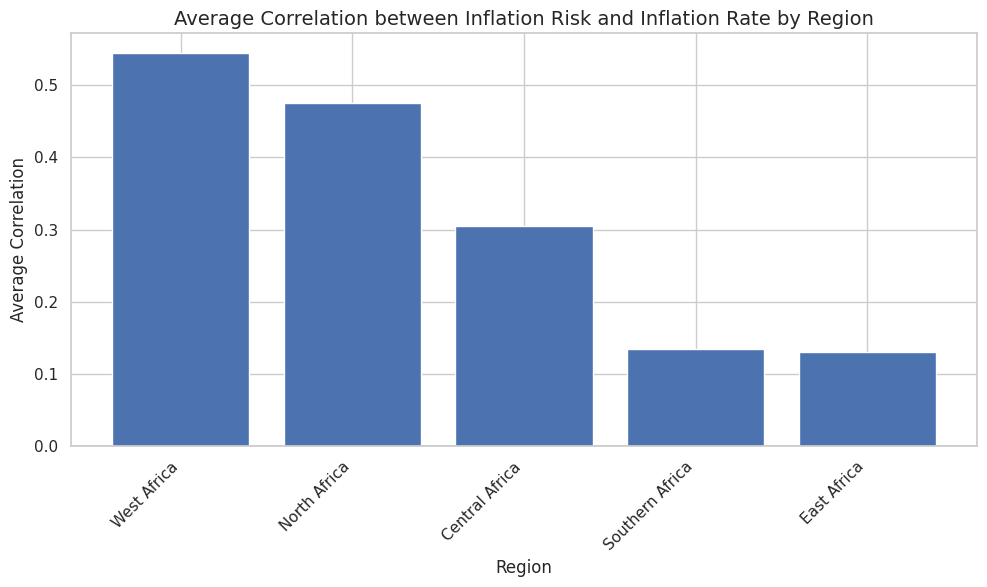

In [54]:
import matplotlib.pyplot as plt

# Convert Series to DataFrame for easier plotting
region_corr_df = region_avg_corr.reset_index()
region_corr_df.columns = ['Region', 'Correlation']

# Bar chart
plt.figure(figsize=(10, 6))

plt.bar(
    region_corr_df['Region'],
    region_corr_df['Correlation']
)

plt.axhline(0, linewidth=1)

plt.title('Average Correlation between Inflation Risk and Inflation Rate by Region',
          fontsize=14)

plt.xlabel('Region')
plt.ylabel('Average Correlation')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [55]:
region_summary = (
    country_corr.groupby('Region')
    .agg(
        Mean_Correlation=('Correlation', 'mean'),
        Number_of_Countries=('Country', 'count')
    )
    .sort_values('Mean_Correlation', ascending=False)
)

print(region_summary)

                 Mean_Correlation  Number_of_Countries
Region                                                
West Africa              0.544593                    3
North Africa             0.475223                    5
Central Africa           0.304529                    1
Southern Africa          0.134032                    2
East Africa              0.130746                    4
